# Example: Yield to Maturity Calculation for a Note (Bond)
In this example, we calculate the yield to maturity (YTM) of a note or bond from its price and promised cash flows. YTM is the single rate, under the stated compounding convention, that equates those promised cash flows to the observed full price. Interpreting it as a realized holding-period return additionally requires holding to maturity, receiving every payment, and reinvesting coupons at the YTM.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
>
> * __Formulate the YTM equation:__ Express a coupon security's full price as the present value of its promised cash flows under a single yield.
> * __Estimate YTM numerically:__ Use the secant method to solve the nonlinear pricing equation and assess convergence.
> * __Interpret YTM carefully:__ Identify the holding, payment, and coupon-reinvestment assumptions required to interpret YTM as a realized return.


Let's estimate and interpret the note's yield to maturity.
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We are going to look at a hypothetical 10-year U.S. Treasury Note. The data for this security is encoded in [the `NamedTuple` data structure](https://docs.julialang.org/en/v1/base/base/#Core.NamedTuple). Let's start with a 10-year U.S. Treasury Note:

In [2]:
note_data = (
    T = "10-Year" |> securityterm,
    n = 2,
    par = 100.0,
    y = 0.0455764, # 4.5% 
    c̄ = 0.035,  # 3.5% coupon
);

Next, let's build an [instance of the `MyUSTreasuryCouponSecurityModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.MyUSTreasuryCouponSecurityModel) using [a custom `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/fixed/#VLQuantitativeFinancePackage.build-Tuple{Type{MyUSTreasuryCouponSecurityModel},%20NamedTuple}), then we'll compute the auction price. We store the priced note in the `test_note_model::MyUSTreasuryCouponSecurityModel` variable.

In [3]:
test_note_model = let

    # initialize -
    discount_model = DiscreteCompoundingModel();
    test_note = nothing; # initialize

    test_note = build(MyUSTreasuryCouponSecurityModel, (
        T = note_data.T, 
        rate = note_data.y, 
        coupon = note_data.c̄, 
        λ = note_data.n, 
        par = note_data.par,
    )) |> discount_model;

    test_note; # return
end;

What's the price of this note at auction? 

In [4]:
test_note_model.price

91.58125282945406

___

## Let's compute the yield to maturity of the note
In this task, we will compute the yield to maturity of the 10-year U.S. Treasury Note using [the `yieldtomaturity(...)` function](src/Compute.jl) that we implemented locally.

> __What is this function doing?__ The [`yieldtomaturity(...)`](src/Compute.jl) function uses the secant method to iteratively solve for the yield to maturity of a bond given its price, coupon payments, and time to maturity. The secant method is a root-finding algorithm that uses two initial guesses to approximate the root of a function. We use the default parameters in this example.

Let's play around with the parameters for the note and see how the yield to maturity changes.

In [5]:
Ȳ, solution_archive = let
    
    # initialize -
    TR = 5.0; # years to maturity
    price = (test_note_model.price)*1.0; # market price

    Y, YTM = yieldtomaturity(test_note_model; TR = TR, price=price);
    println("The yield to maturity of a U.S. Treasury Note with maturity in $(TR) years is approximately $(round(Y*100, digits=4))%")

    Y,YTM
end;

The yield to maturity of a U.S. Treasury Note with maturity in 5.0 years is approximately 5.4461%


__Curious:__ How many iterations did it take to converge to a solution?

In [6]:
length(solution_archive)

6

### Discussion
1. Holding full price, coupon rate, and par value fixed, how does the solved YTM change when remaining maturity changes? Is the direction universal, or does it depend on whether the fixed price is above, below, or equal to par?
2. If the time to maturity is fixed, how does a change in the price of the bond affect its yield to maturity?

### Why should we expect the secant method to work?
The secant method is a numerical technique used to find the roots of a function. In the context of calculating the yield to maturity (YTM) of a note (bond), we are trying to find the discount rate that equates the present value of the bond's future cash flows (coupon payments and face value at maturity) to its current market price.

> __Strictly decreasing function__: The $\texttt{NPV}(\bar{Y})$ function for a note (bond) is strictly decreasing with respect to the discount rate (YTM) (our variable $\bar{Y}$). This means that as the discount rate increases, the present value of the bond's cash flows decreases. Conversely, as the discount rate decreases, the present value of the bond's cash flows increases. This property ensures that there is a unique solution (root) for the YTM, as the NPV function will cross zero only once.

What does the NPV function look like for a note (bond)?

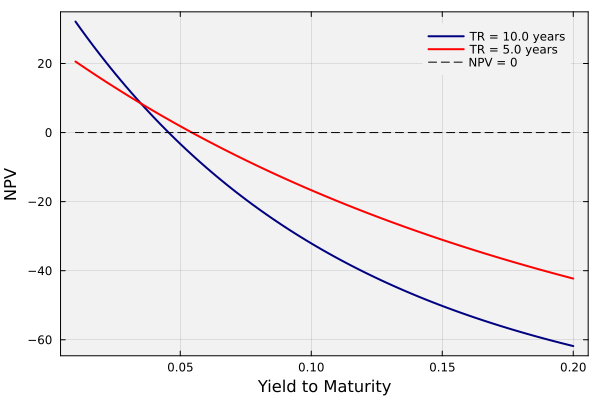

In [7]:
let

    # initialize -
    number_of_points = 100;
    Y = range(0.01, 0.20, length=number_of_points); # yield range
    TR = 10.0; # time to maturity
    VB = test_note_model.price;
    NPV_array_1 = [_net_present_value(test_note_model, y; TR = TR, price = VB) for y in Y];
    NPV_array_2 = [_net_present_value(test_note_model, y; TR=0.5*TR, price = VB) for y in Y];

    # break-even yield to maturity is where NPV = 0
    BEL = zeros(number_of_points);

    plot(Y,NPV_array_1, label="TR = $TR years", xlabel="Yield to Maturity", ylabel="NPV", legend=:topright, lw=2, c=:navy)
    plot!(Y,NPV_array_2, label="TR = $(0.5*TR) years", lw=2, c=:red)
    plot!(Y,BEL, label="NPV = 0", linestyle=:dash, color=:black)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

___

## Summary

This example estimated the yield to maturity of a coupon security by solving the nonlinear equation that equates its observed full price with the present value of its promised cash flows.

> __Key Takeaways:__
>
> * __YTM is an internal rate of return for promised cash flows:__ One yield is applied to every coupon and the principal repayment so their discounted value equals the security's full price.
> * __The pricing equation generally requires numerical solution:__ The secant method updates yield guesses from pricing residuals until the residual or yield change satisfies a stated convergence tolerance.
> * __Realizing YTM requires strong assumptions:__ The investor must hold to maturity, receive every promised payment, and reinvest coupons at the estimated yield.

Yield to maturity is a useful single-number summary, but it is not a guaranteed realized return and should be interpreted together with its payment and reinvestment assumptions.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
___